# **TV4 – Comparison / Relationship: Correlation, Scatterplot, Pairplot, Heatmap**
Dataset: House Prices (Ames, Iowa) – `train.csv`. Biến mục tiêu: `SalePrice`.

Phần này tìm **mối quan hệ giữa các biến**, đặc biệt là giữa các biến với `SalePrice`.
Cấu trúc bám theo notebook bài mẫu (Iris): *Correlation → Scatterplots → Pairplot (Correlogram) → Heatmap*.

> **Lưu ý:** EDA chỉ cho thấy **mối quan hệ/tương quan**, chưa chứng minh **quan hệ nhân quả**.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('train.csv')
df.shape

(1460, 81)

## **Chuẩn bị**
`Id` chỉ là số thứ tự, và `MSSubClass` được lưu dạng số nhưng thực chất là **mã loại nhà** (biến phân loại). Cả hai không có ý nghĩa khi tính tương quan nên được loại khỏi phần này (dữ liệu gốc `df` không bị thay đổi).

*Ghi chú đối chiếu:* TV1 đếm 36 biến numerical (gồm `MSSubClass`); phần TV4 chỉ dùng 35 biến vì đã loại `MSSubClass`.

In [2]:
data = df.drop(columns=['Id', 'MSSubClass'])
print('Số biến số dùng để tính tương quan:', data.select_dtypes('number').shape[1])

Số biến số dùng để tính tương quan: 36


# **1. Correlation**
Hệ số tương quan Pearson (từ −1 đến 1) đo mức **tuyến tính** giữa hai biến số. Giá trị gần ±1: quan hệ mạnh; gần 0: yếu. `pandas` tự bỏ qua ô trống (NaN) theo từng cặp biến.

In [3]:
corr = data.corr(numeric_only=True)
corr

,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
LotFrontage,1.000000,0.426095,0.251646,-0.059213,0.123349,0.088866,0.193458,0.233633,0.049900,0.132644,...,0.088521,0.151972,0.010700,0.070029,0.041383,0.206167,0.003368,0.011200,0.007450,0.351799
LotArea,0.426095,1.000000,0.105806,-0.005636,0.014228,0.013788,0.104160,0.214103,0.111170,-0.002618,...,0.171698,0.084774,-0.018340,0.020423,0.043160,0.077672,0.038068,0.001205,-0.014261,0.263843
OverallQual,0.251646,0.105806,1.000000,-0.091932,0.572323,0.550684,0.411876,0.239666,-0.059119,0.308159,...,0.238923,0.308819,-0.113937,0.030371,0.064886,0.065166,-0.031406,0.070815,-0.027347,0.790982
OverallCond,-0.059213,-0.005636,-0.091932,1.000000,-0.375983,0.073741,-0.128101,-0.046231,0.040229,-0.136841,...,-0.003334,-0.032589,0.070356,0.025504,0.054811,-0.001985,0.068777,-0.003511,0.043950,-0.077856
YearBuilt,0.123349,0.014228,0.572323,-0.375983,1.000000,0.592855,0.315707,0.249503,-0.049107,0.149040,...,0.224880,0.188686,-0.387268,0.031355,-0.050364,0.004950,-0.034383,0.012398,-0.013618,0.522897
YearRemodAdd,0.088866,0.013788,0.550684,0.073741,0.592855,1.000000,0.179618,0.128451,-0.067759,0.181133,...,0.205726,0.226298,-0.193919,0.045286,-0.038740,0.005829,-0.010286,0.021490,0.035743,0.507101
MasVnrArea,0.193458,0.104160,0.411876,-0.128101,0.315707,0.179618,1.000000,0.264736,-0.072319,0.114442,...,0.159718,0.125703,-0.110204,0.018796,0.061466,0.011723,-0.029815,-0.005965,-0.008201,0.477493
BsmtFinSF1,0.233633,0.214103,0.239666,-0.046231,0.249503,0.128451,0.264736,1.000000,-0.050117,-0.495251,...,0.204306,0.111761,-0.102303,0.026451,0.062021,0.140491,0.003571,-0.015727,0.014359,0.386420
BsmtFinSF2,0.049900,0.111170,-0.059119,0.040229,-0.049107,-0.067759,-0.072319,-0.050117,1.000000,-0.209294,...,0.067898,0.003093,0.036543,-0.029993,0.088871,0.041709,0.004940,-0.015211,0.031706,-0.011378
BsmtUnfSF,0.132644,-0.002618,0.308159,-0.136841,0.149040,0.181133,0.114442,-0.495251,-0.209294,1.000000,...,-0.005316,0.129005,-0.002538,0.020764,-0.012579,-0.035092,-0.023837,0.034888,-0.041258,0.214479


Tương quan của các biến với `SalePrice`, sắp xếp giảm dần:

In [4]:
corr['SalePrice'].sort_values(ascending=False)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64

Bảng gọn để đưa vào slide: Top 10 biến, kèm Spearman (đo quan hệ **đơn điệu**, ít bị ảnh hưởng bởi điểm lạ) để so sánh.

In [5]:
corr_table = pd.DataFrame({
    'Pearson' : corr['SalePrice'],
    'Spearman': data.corr(numeric_only=True, method='spearman')['SalePrice']
}).drop('SalePrice')
corr_table = corr_table.reindex(corr_table['Pearson'].abs().sort_values(ascending=False).index)
corr_table.head(10).round(3)

,Pearson,Spearman
OverallQual,0.791,0.810
GrLivArea,0.709,0.731
GarageCars,0.640,0.691
GarageArea,0.623,0.649
TotalBsmtSF,0.614,0.603
1stFlrSF,0.606,0.575
FullBath,0.561,0.636
TotRmsAbvGrd,0.534,0.533
YearBuilt,0.523,0.653
YearRemodAdd,0.507,0.571


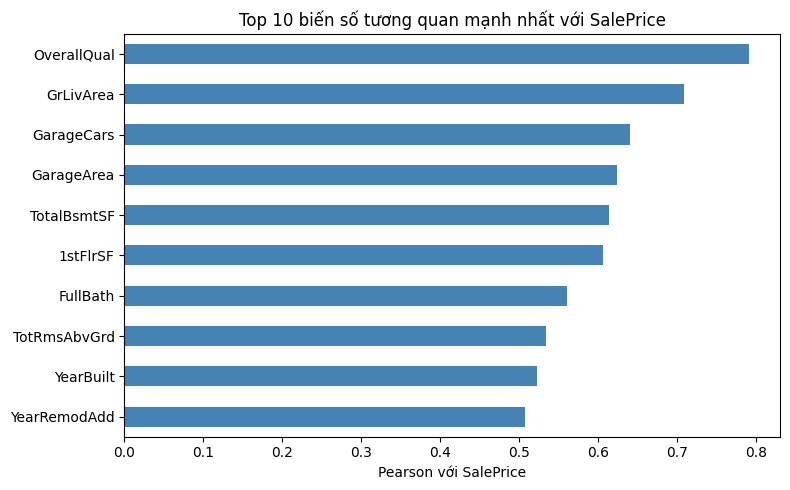

In [6]:
top = corr_table.head(10).iloc[::-1]
top['Pearson'].plot.barh(figsize=(8,5), color='steelblue')
plt.xlabel('Pearson với SalePrice'); plt.title('Top 10 biến số tương quan mạnh nhất với SalePrice')
plt.tight_layout(); plt.savefig('fig_top_corr.png', dpi=130); plt.show()

### What we can conclude:
- `OverallQual` tương quan mạnh nhất với `SalePrice` (r ≈ 0,79), kế đến là `GrLivArea` (≈ 0,71), `GarageCars` (≈ 0,64), `GarageArea` (≈ 0,62), `TotalBsmtSF` (≈ 0,61) và `1stFlrSF` (≈ 0,61). Đó là nhóm **chất lượng** và **diện tích/quy mô**.
- `YearBuilt` có Spearman (≈ 0,65) cao hơn Pearson (≈ 0,52): giá tăng theo năm xây nhưng không thuần tuyến tính.
- Nhiều biến gần như không liên quan tuyến tính tới giá (|r| < 0,05), ví dụ `MiscVal`, `LowQualFinSF`, `YrSold`.
- Chỉ có tương quan âm yếu ở vài biến như `KitchenAbvGr` (≈ −0,14) và `EnclosedPorch` (≈ −0,13).

# **2. Comparison graphs – Scatterplots**
**What?** Dùng hệ tọa độ Descartes để hiển thị giá trị của hai biến cho tất cả quan sát.

**Why?** Cho thấy hình dạng quan hệ giữa hai biến (tuyến tính, đường cong, phân tán nhiều hay ít), điều mà một con số tương quan không cho thấy hết.

Bắt đầu với biến diện tích sinh hoạt `GrLivArea` và `SalePrice`:

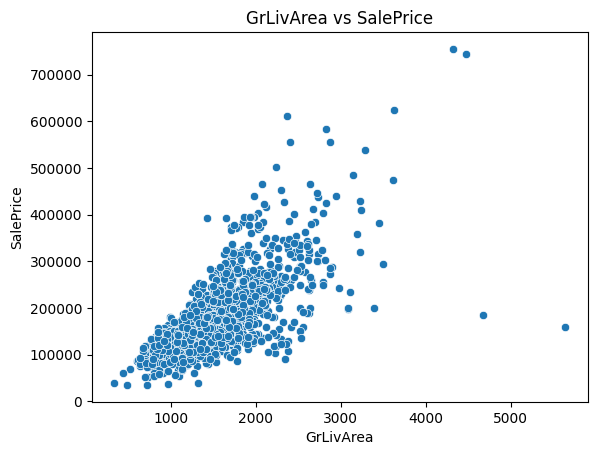

In [7]:
sns.scatterplot(data=df, x='GrLivArea', y='SalePrice')
plt.title('GrLivArea vs SalePrice')
plt.savefig('fig_scatter_grlivarea.png', dpi=130); plt.show()

Tô màu theo nhóm chất lượng tổng thể (tương tự `hue` theo `species` trong bài mẫu). `QualGroup` là cột tạm chỉ dùng để vẽ.

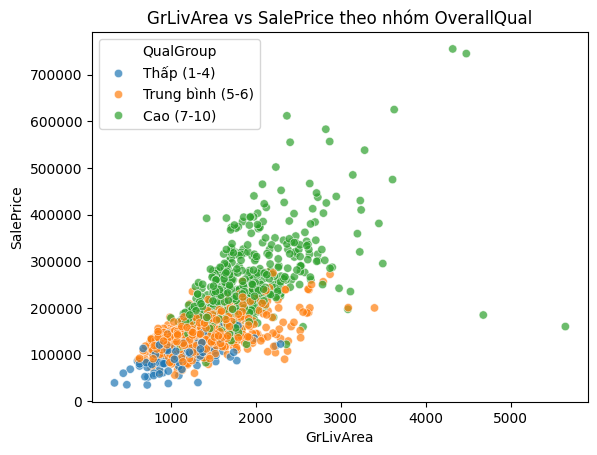

In [8]:
df['QualGroup'] = pd.cut(df['OverallQual'], bins=[0,4,6,10],
                         labels=['Thấp (1-4)', 'Trung bình (5-6)', 'Cao (7-10)'])
sns.scatterplot(data=df, x='GrLivArea', y='SalePrice', hue='QualGroup', alpha=0.7)
plt.title('GrLivArea vs SalePrice theo nhóm OverallQual')
plt.savefig('fig_scatter_grlivarea_hue.png', dpi=130); plt.show()

Các cặp còn lại với `SalePrice`:

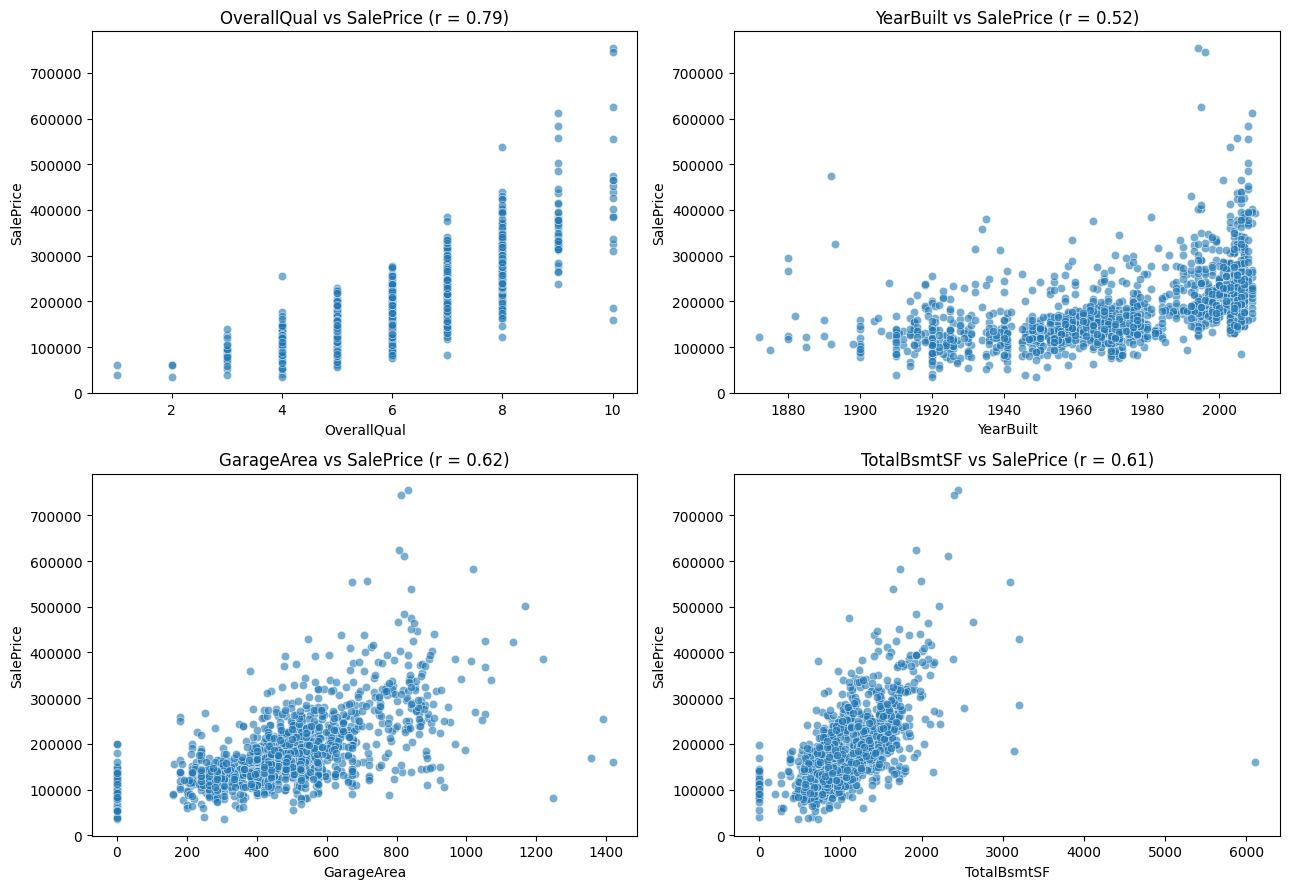

In [9]:
fig, ax = plt.subplots(2, 2, figsize=(13, 9))
for a, f in zip(ax.ravel(), ['OverallQual', 'YearBuilt', 'GarageArea', 'TotalBsmtSF']):
    sns.scatterplot(data=df, x=f, y='SalePrice', ax=a, alpha=0.6)
    a.set_title(f'{f} vs SalePrice (r = {df[f].corr(df["SalePrice"]):.2f})')
plt.tight_layout(); plt.savefig('fig_scatter_4.png', dpi=130); plt.show()

### What we can conclude:
- **`GrLivArea`:** diện tích càng lớn thì giá có xu hướng càng cao (r ≈ 0,71). Hai điểm ở góc phải dưới (Id 524 và 1299, cùng thuộc khu Edwards; 4676 và 5642 ft², giá 184.750 và 160.000 USD) nằm xa xu hướng chung; khi bỏ hai điểm này r tăng lên ≈ 0,74.
- **`OverallQual`:** giá tăng rõ theo mức chất lượng, và **độ phân tán giá cũng tăng theo mức** (độ lệch chuẩn khoảng 27 nghìn ở mức 5, 44 nghìn ở mức 7, 81 nghìn ở mức 9). Đây là biến rời rạc nên các điểm xếp thành cột.
- **`YearBuilt`:** nhà xây mới hơn thường có giá cao hơn (giá trung vị khoảng 122 nghìn cho nhà xây đến 1950, 143 nghìn cho 1951–1980, 197 nghìn cho 1981–2000, 225 nghìn cho sau 2000). Quan hệ yếu hơn các biến trên và phân tán nhiều.
- **`GarageArea`:** 81 nhà có `GarageArea = 0` (không có gara; trùng đúng 81 nhà bị thiếu `GarageType` trong bảng missing của TV2) tạo thành cột điểm sát trục dọc; phần còn lại giá tăng theo diện tích gara.
- **`TotalBsmtSF`:** 37 nhà `TotalBsmtSF = 0` (không có tầng hầm; trùng đúng 37 nhà thiếu `BsmtQual`) cũng tạo cột điểm tương tự; phần còn lại giá tăng theo diện tích hầm.
- Căn nhà có `GrLivArea` = 5642 (Id 1299) cũng là điểm cực đoan ở `TotalBsmtSF` (6110) và `GarageArea` (1418), giá chỉ 160.000: đây là **một quan sát bất thường nổi bật** xuất hiện ở nhiều biểu đồ.

> *Việc đánh giá đây có phải outlier/lỗi dữ liệu và giữ hay loại thuộc phần TV5; TV4 chỉ mô tả hiện tượng quan sát được.*

# **3. Correlogram – Pairplot**
Pairplot vẽ scatterplot cho **từng cặp** biến số, đường chéo là phân phối của từng biến. Với House Prices không nên đưa toàn bộ ~80 biến vào (rất nặng, khó đọc), nên chọn một nhóm nhỏ gồm biến mục tiêu và các biến có tương quan cao.

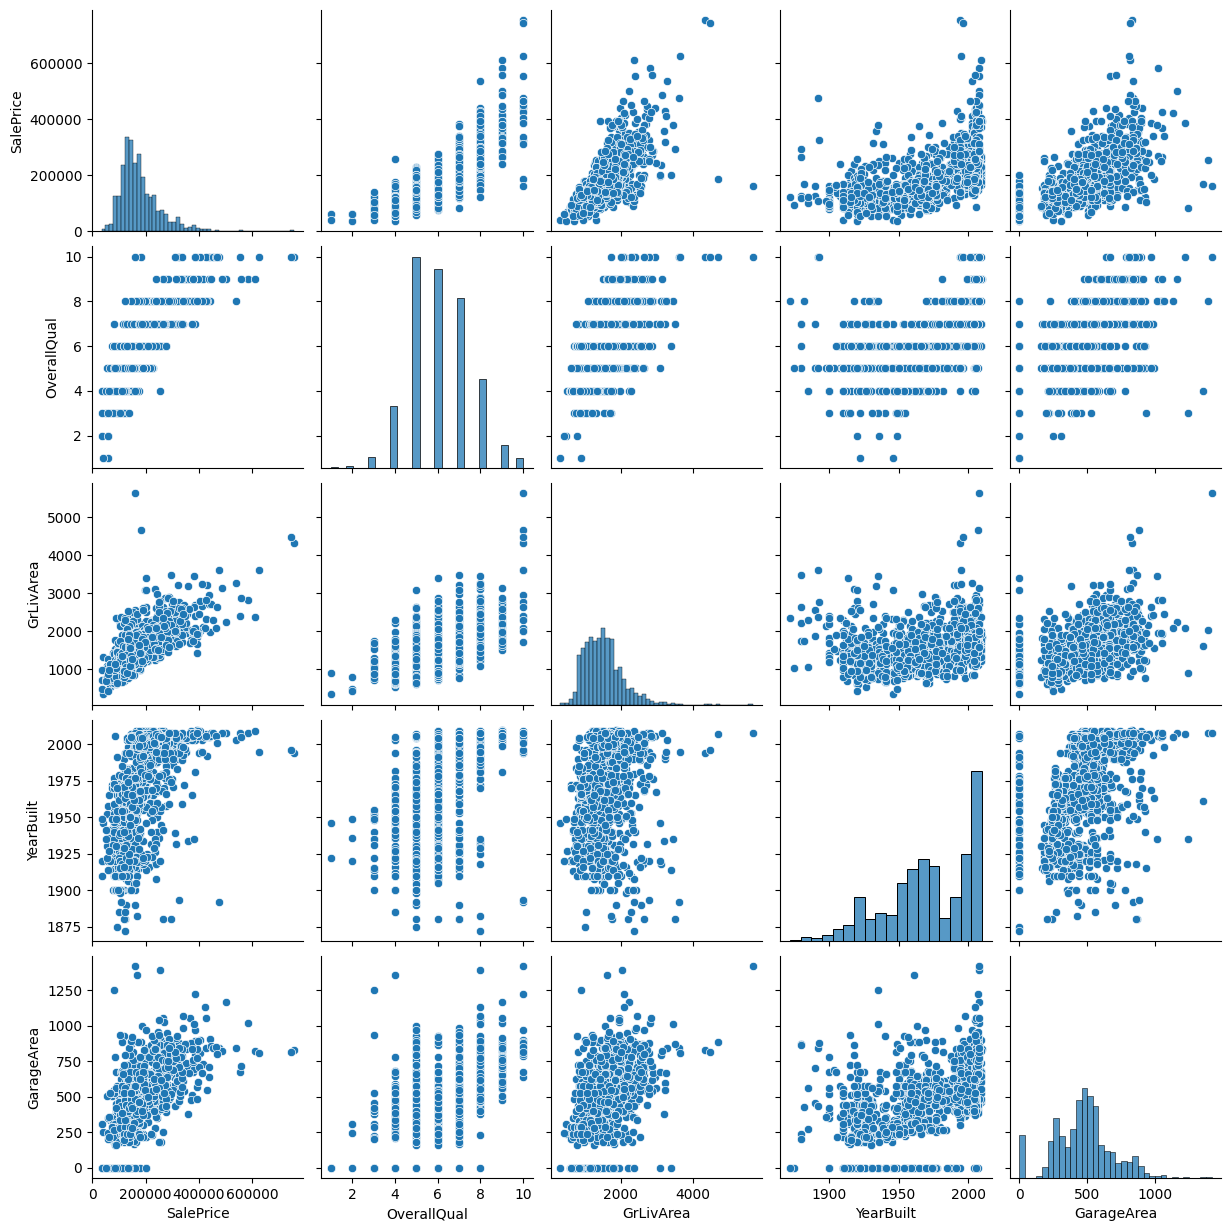

In [10]:
cols = ['SalePrice', 'OverallQual', 'GrLivArea', 'YearBuilt', 'GarageArea']
sns.pairplot(df[cols])
plt.savefig('fig_pairplot.png', dpi=110); plt.show()

Tô màu theo nhóm chất lượng tổng thể:

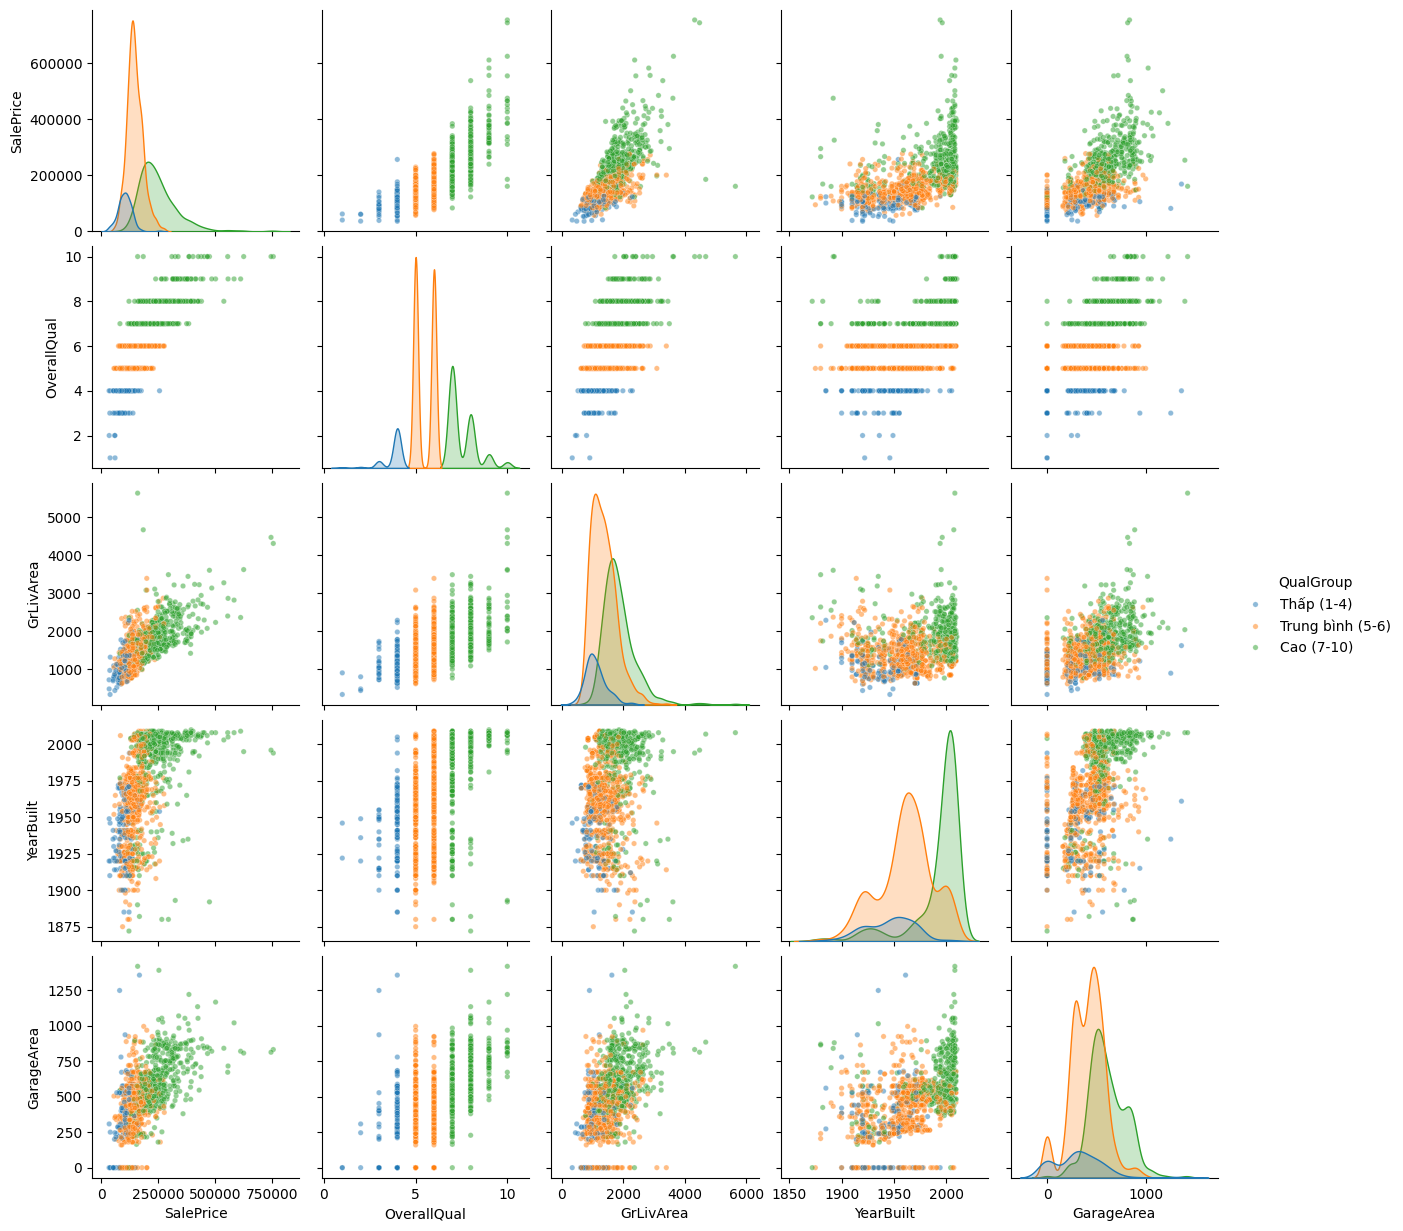

In [11]:
sns.pairplot(df[cols + ['QualGroup']], hue='QualGroup', diag_kind='kde',
             plot_kws={'alpha': 0.5, 's': 15})
plt.savefig('fig_pairplot_hue.png', dpi=110); plt.show()

In [12]:
df.groupby('QualGroup')[cols].median().round(0)

,SalePrice,OverallQual,GrLivArea,YearBuilt,GarageArea
QualGroup,,,,,
Thấp (1-4),105000.0,4.0,1040.0,1949.0,296.0
Trung bình (5-6),143000.0,5.0,1302.0,1963.0,431.0
Cao (7-10),230000.0,7.0,1734.0,2002.0,576.0


### What we can conclude:
- Hàng/cột `SalePrice` cho thấy giá tăng cùng `OverallQual`, `GrLivArea` và `GarageArea`; với `YearBuilt` xu hướng tăng yếu hơn.
- Theo nhóm chất lượng, nhóm **Cao (7–10)** có giá trung vị ≈ 230 nghìn, `GrLivArea` ≈ 1734, xây khoảng 2002 và gara ≈ 576 ft². Nhóm **Thấp (1–4)** lần lượt chỉ ≈ 105 nghìn, 1040, 1949 và 296. Nhóm **Trung bình (5–6)** nằm giữa (≈ 143 nghìn, 1302, 1963, 431).
- Nhóm chất lượng cao thường là nhà lớn hơn, xây mới hơn và gara rộng hơn, nên `OverallQual` có liên hệ với nhiều đặc điểm khác (tương quan với `YearBuilt` ≈ 0,57, với `GrLivArea` ≈ 0,59).
- Cặp `GrLivArea`–`YearBuilt` gần như không có quan hệ (r ≈ 0,20): nhà mới không nhất thiết lớn hơn.
- Trên các biểu đồ có `GarageArea` thấy cột điểm tại 0 (nhà không có gara) và một vài điểm cực đoan bên phải.

# **4. Heatmap**
Heatmap biểu diễn ma trận tương quan bằng màu: màu đậm là |r| lớn. Trước hết là nhóm biến đã chọn ở pairplot.

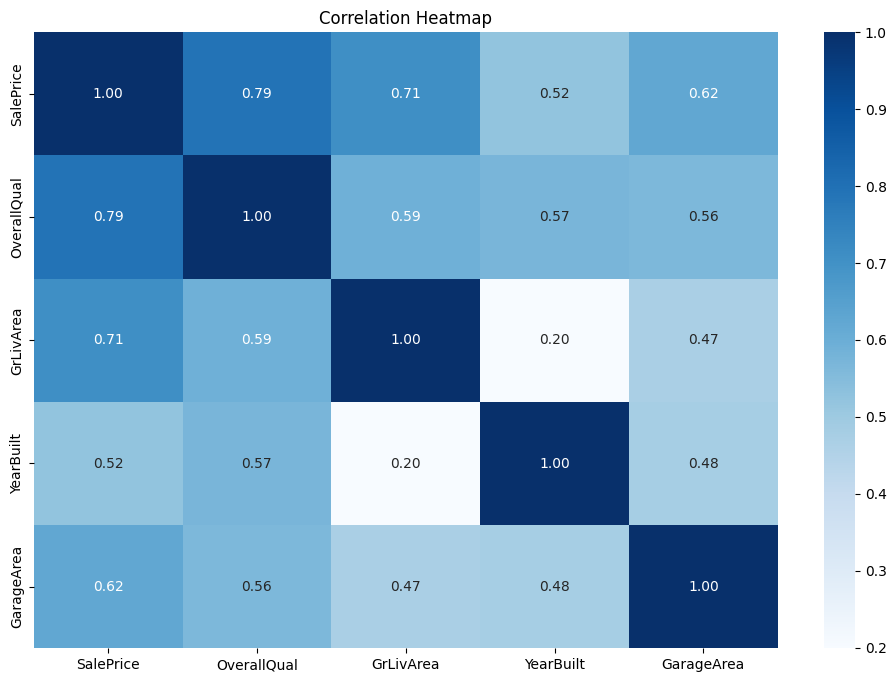

In [13]:
plt.figure(figsize=(12, 8))
sns.heatmap(df[cols].corr(), annot=True, fmt='.2f', cmap='Blues')
plt.title('Correlation Heatmap')
plt.savefig('fig_heatmap.png', dpi=130); plt.show()

Mở rộng sang 10 biến số tương quan mạnh nhất với `SalePrice` để kiểm tra **đa cộng tuyến** (các biến đầu vào tương quan mạnh với nhau):

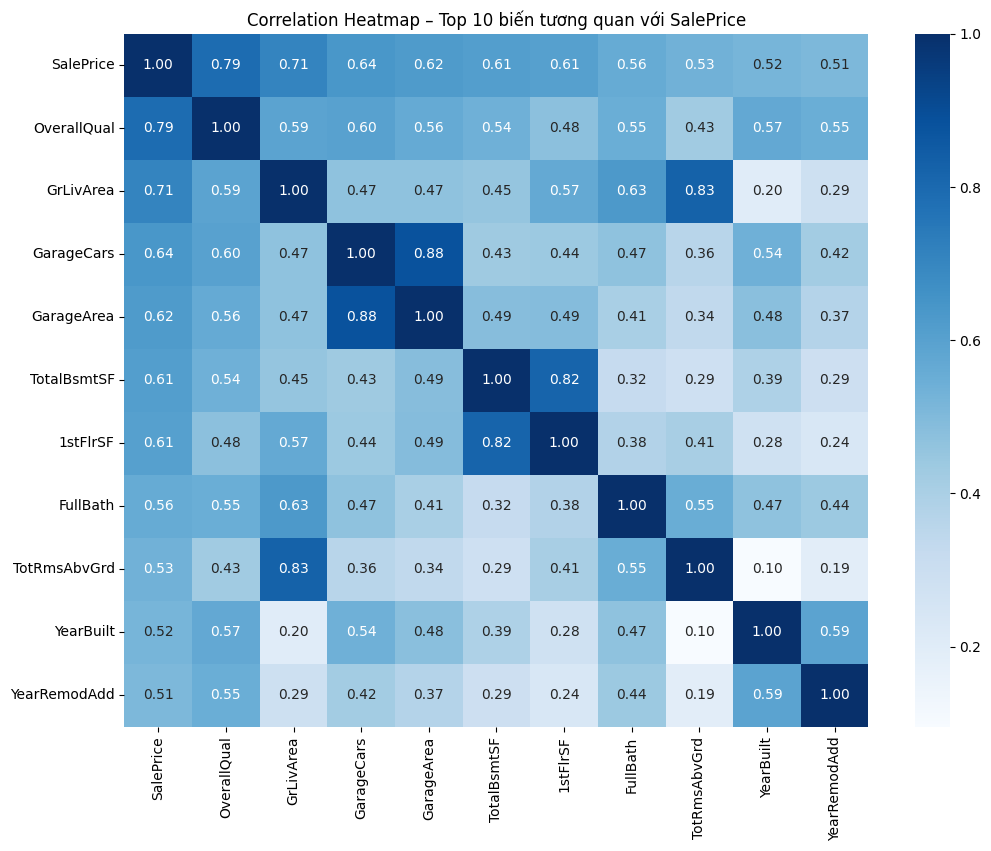

In [14]:
top10 = corr_table.head(10).index.tolist()
plt.figure(figsize=(12, 9))
sns.heatmap(data[['SalePrice'] + top10].corr(), annot=True, fmt='.2f', cmap='Blues')
plt.title('Correlation Heatmap – Top 10 biến tương quan với SalePrice')
plt.savefig('fig_heatmap_top10.png', dpi=130); plt.show()

In [15]:
# Các cặp biến đầu vào có |r| > 0.7
c = data[top10].corr()
pairs = [(a, b, round(c.loc[a, b], 3)) for i, a in enumerate(top10) for b in top10[i+1:] if abs(c.loc[a, b]) > 0.7]
pd.DataFrame(pairs, columns=['Biến A', 'Biến B', 'Pearson']).sort_values('Pearson', ascending=False)

,Biến A,Biến B,Pearson
1,GarageCars,GarageArea,0.882
0,GrLivArea,TotRmsAbvGrd,0.825
2,TotalBsmtSF,1stFlrSF,0.820


### What we can conclude:
- Trong nhóm 5 biến: `SalePrice` tương quan với `OverallQual` (0,79), `GrLivArea` (0,71), `GarageArea` (0,62) và `YearBuilt` (0,52). Các biến đầu vào tương quan với nhau ở mức vừa phải (tối đa 0,59), nên nhóm này ít trùng thông tin.
- Trong top 10 có ba cặp biến đầu vào tương quan rất mạnh: `GarageCars`–`GarageArea` (0,88), `GrLivArea`–`TotRmsAbvGrd` (0,83) và `TotalBsmtSF`–`1stFlrSF` (0,82). Mỗi cặp mô tả gần cùng một đặc điểm, nên với mô hình tuyến tính nên giữ một biến đại diện (gây **đa cộng tuyến**). Mô hình cây ít bị ảnh hưởng hơn.

# **5. Nhận xét tổng hợp các mối quan hệ đáng chú ý (TV4)**
1. **Chất lượng và diện tích** là hai nhóm đặc điểm liên quan mạnh nhất tới giá: `OverallQual` (0,79), `GrLivArea` (0,71), tiếp đến là các biến về gara và tầng hầm.
2. **Quan hệ không đều ở mọi mức:** độ phân tán giá tăng theo `OverallQual`, nên cùng mức chất lượng cao thì giá chênh lệch nhiều.
3. **Giá trị 0 mang ý nghĩa "không có"** ở `GarageArea` và `TotalBsmtSF`, làm scatterplot có cột điểm sát trục, cần lưu ý khi đọc tương quan.
4. **Đa cộng tuyến** tồn tại giữa `GarageCars`–`GarageArea`, `GrLivArea`–`TotRmsAbvGrd`, `TotalBsmtSF`–`1stFlrSF`.
5. **Quan sát bất thường:** một căn nhà cực đoan đồng thời ở `GrLivArea`, `TotalBsmtSF`, `GarageArea` làm lệch xu hướng (chuyển TV5 đánh giá).
6. **Giới hạn:** đây là các mối quan hệ thống kê, **không** kết luận nhân quả (ví dụ không nói "`OverallQual` làm tăng `SalePrice`", mà nói "`SalePrice` có xu hướng thay đổi theo `OverallQual`").